# Production Forecast - Single Scenario by Country

## Purpose
This notebook generates oil production forecasts for a specific country and scenario combination using time series analysis. It is designed to be called programmatically by a parent orchestration notebook.

## Key Features
* **Parameterized execution**: Receives `country` and `scenario` parameters via dbutils widgets
* **Scenario modeling**: Supports baseline forecasts and event-driven scenarios with exogenous variables
* **Special data handling**: Includes interpolation logic for Russia's missing 1984 data
* **Time series methods**: Implements SARIMA (Seasonal AutoRegressive Integrated Moving Average) models
* **Comprehensive analysis**: Performs seasonal decomposition, stationarity testing, and model optimization

## Workflow
1. Load and validate input parameters (country and scenario)
2. Sanitize names for database table creation
3. Load exogenous variables for non-baseline scenarios from `gold.exogenous_variables`
4. Load historical production data from `gold.prod_timeseries_monthly`
5. Align exogenous variables with time series dates
6. Perform exploratory data analysis (visualization, seasonal decomposition)
7. Test for stationarity and determine differencing requirements
8. Optimize SARIMA model parameters (Cell 35)
9. Train and compare SARIMA and Prophet models on test set (Cells 35-49)
10. Retrain both SARIMA and Prophet models on full dataset (Cell 54)
11. Select winning model and generate 60-month forecast (Cell 55)
12. Extract and save exogenous variable coefficient (Cell 58)
13. Save model performance metrics to database (Cell 60)

## Data Sources
* **Historical production**: `gold.prod_timeseries_monthly`
* **Exogenous variables**: `gold.exogenous_variables` (for event scenarios)

## Output
* **Monthly forecasts**: `workspace.gold.production_forecast_table_monthly` - 60-month forecast with confidence intervals (Total_crude, Total_Lower_Bound, Total_Upper_Bound)
* **Model performance metrics**: `workspace.gold.model_metrics` - Winning model name, MAPE, exogenous variable coefficient, and run timestamp for each country-scenario-direction combination


In [0]:
# Receive parameters from calling notebook
dbutils.widgets.text("country", "")
dbutils.widgets.text("scenario", "")

country = dbutils.widgets.get("country")
scenario = dbutils.widgets.get("scenario")

# Validate that parameters were passed
if not country or not scenario:
    raise ValueError(f"Missing required parameters! country='{country}', scenario='{scenario}'. This notebook must be called with both parameters.")

print(f"Running forecast for:")
print(f"  Country: {country}")
print(f"  Scenario: {scenario}")

Running forecast for:
  Country: Canada
  Scenario: COVID Shutdowns


In [0]:
import re

def sanitize_table_name(name):
    """
    Sanitize a string to be a valid SQL table name component.
    - Converts to lowercase
    - Replaces spaces, hyphens, and all non-alphanumeric characters with underscores
    - Removes consecutive underscores
    - Removes leading/trailing underscores
    """
    # Convert to lowercase
    name = name.lower()
    # Replace all non-alphanumeric characters (including spaces, hyphens, parentheses, etc.) with underscores
    name = re.sub(r'[^a-z0-9]+', '_', name)
    # Remove leading/trailing underscores
    name = name.strip('_')
    return name

# Sanitize country and scenario for use in table names
country_sanitized = sanitize_table_name(country)
scenario_sanitized = sanitize_table_name(scenario)

print(f"Sanitized names for table creation:")
print(f"  Country: '{country}' → '{country_sanitized}'")
print(f"  Scenario: '{scenario}' → '{scenario_sanitized}'")

Sanitized names for table creation:
  Country: 'Canada' → 'canada'
  Scenario: 'COVID Shutdowns' → 'covid_shutdowns'


In [0]:
# Initialize exogenous_variables as None (will be loaded for non-Baseline scenarios)
exogenous_variables_full = None

if scenario != 'Baseline scenario':
    #load the exogenous variables from workspace.gold.exogenous_variables into an array
    #get the row and convert to list, dropping first metadata columns (Country, Event_Direction, Event_Type, Description, Coefficient, generic_name)
    row = spark.sql(f"SELECT * FROM gold.exogenous_variables WHERE Country = '{country}' AND Description = '{scenario}' AND Event_Direction = 'Production'").collect()[0]
    exogenous_variables_raw = list(row)[6:]  # Keep only date columns (starting from 1973-01), skip first 6 metadata columns
    
    #now add 5 year's worth of 1s to the end of the array. That's 60 1s for future forecast
    exogenous_variables_raw.extend([1]*60)
    
    # Get the start date from exogenous_variables table (first date column name)
    exog_start_date = '1973-01'
    
    # Store the full exogenous variables array for later alignment
    exogenous_variables_full = exogenous_variables_raw
    
    print(f"Loaded {len(exogenous_variables_full)} exogenous variable values (1973-01 to {60} months beyond data)")


Loaded 698 exogenous variable values (1973-01 to 60 months beyond data)


In [0]:
# If the country is Russia, interpolate missing 1984 data
if country == 'Russia':
    #load data for Russia and Former U.S.S.R. from gold.prod_timeseries into a dataframe 
    df = spark.sql(f"""
    SELECT Country, Date, value AS Oil_Prod
    FROM gold.prod_timeseries_monthly
    WHERE Country IN ('Russia', 'Former U.S.S.R.')
    ORDER BY Date ASC
    """)
    # the data is missing for all periods of 1984. Interpolate by taking the average of December 1983 and January 1985
    df_pd = df.toPandas()
    # Find December 1983 and January 1985 values for Former U.S.S.R.
    dec_1983 = df_pd[(df_pd['Country'] == 'Former U.S.S.R.') & (df_pd['Date'] == '1983-12')]['Oil_Prod'].values[0]
    jan_1985 = df_pd[(df_pd['Country'] == 'Former U.S.S.R.') & (df_pd['Date'] == '1985-01')]['Oil_Prod'].values[0]
    interp_value = (dec_1983 + jan_1985) / 2

    print(f"Dec 1983: {dec_1983}, Jan 1985: {jan_1985}, Interpolated: {interp_value}")

    # Create new rows for 1984-01 through 1984-12
    import pandas as pd
    new_rows = []
    for month in range(1, 13):
        new_rows.append({
            'Country': 'Former U.S.S.R.',
            'Date': f'1984-{str(month).zfill(2)}',
            'Oil_Prod': interp_value
        })

    # Create DataFrame from new rows and concatenate
    new_df = pd.DataFrame(new_rows)
    df_pd = pd.concat([df_pd, new_df], ignore_index=True)

    # Sort by Country and Date to maintain chronological order
    df_pd = df_pd.sort_values(['Country', 'Date']).reset_index(drop=True)

    print(f"\nAdded {len(new_rows)} rows for 1984. Total rows: {len(df_pd)}")
else:
    # For all other countries, just load and convert to pandas
    df = spark.sql(f"""SELECT Country, Date, value AS Oil_Prod 
               FROM gold.prod_timeseries_monthly 
               WHERE Country = '{country}'
               ORDER BY Date ASC""")
    df_pd = df.toPandas()

In [0]:
# Align exogenous variables with the time series data dates
if scenario != 'Baseline scenario' and exogenous_variables_full is not None:
    import pandas as pd
    from dateutil.relativedelta import relativedelta
    
    # Get the first date in our time series
    ts_start_date = pd.to_datetime(df_pd['Date'].iloc[0])
    exog_start_date = pd.to_datetime('1973-01-01')
    
    # Calculate the number of months to skip in exogenous_variables
    months_diff = (ts_start_date.year - exog_start_date.year) * 12 + (ts_start_date.month - exog_start_date.month)
    
    # Extract the aligned portion: from ts_start to end of data + 60 months forecast
    exogenous_variables = exogenous_variables_full[months_diff:months_diff + len(df_pd) + 60]
    
    print(f"Aligned exogenous variables:")
    print(f"  Time series starts: {ts_start_date.strftime('%Y-%m')}")
    print(f"  Skipped {months_diff} months from exog data")
    print(f"  Aligned length: {len(exogenous_variables)} (matching {len(df_pd)} historical + 60 forecast)")
    print(f"  First 12 values: {exogenous_variables[:12]}")
else:
    exogenous_variables = None
    print("No exogenous variables (Baseline scenario)")

Aligned exogenous variables:
  Time series starts: 1973-01
  Skipped 0 months from exog data
  Aligned length: 698 (matching 638 historical + 60 forecast)
  First 12 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [0]:
import time
from datetime import datetime

# Record start time
notebook_start_time = time.time()
print(f"Notebook execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook execution started at: 2026-08-06 15:57:52


View the data

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


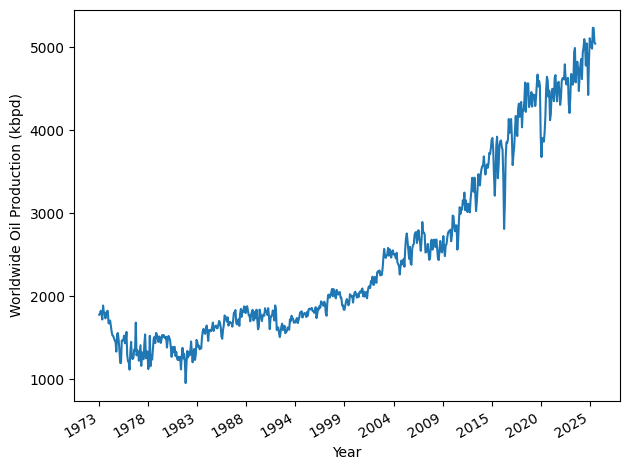

In [0]:
%pip install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

from statsmodels.tsa.seasonal import seasonal_decompose, STL

#plot the data
fig, ax = plt.subplots()

ax.plot(df_pd.Date, df_pd.Oil_Prod)
ax.set_xlabel('Year')
ax.set_ylabel('Worldwide Oil Production (kbpd)')

# Generate dynamic tick labels from actual data
n_ticks = 10
tick_positions = np.arange(0, len(df_pd), max(1, len(df_pd)//n_ticks))
tick_labels = [pd.to_datetime(df_pd['Date'].iloc[min(i, len(df_pd)-1)]).year for i in tick_positions]
plt.xticks(tick_positions, tick_labels)

fig.autofmt_xdate()
plt.tight_layout()

Conduct the seasonal decomposition

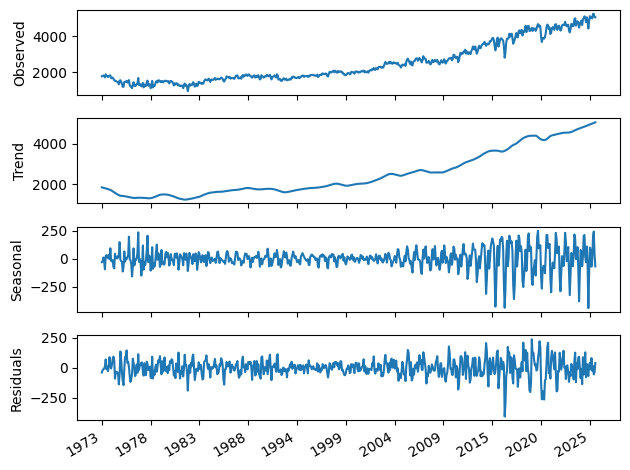

In [0]:
advanced_decomposition = STL(df_pd.Oil_Prod, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True)

ax1.plot(advanced_decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(advanced_decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(advanced_decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(advanced_decomposition.resid)
ax4.set_ylabel('Residuals')


# Generate dynamic tick labels from actual data
n_ticks = 10
tick_positions = np.arange(0, len(df_pd), max(1, len(df_pd)//n_ticks))
tick_labels = [pd.to_datetime(df_pd['Date'].iloc[min(i, len(df_pd)-1)]).year for i in tick_positions]
plt.xticks(tick_positions, tick_labels)

fig.autofmt_xdate()
plt.tight_layout()

 Test for stationarity

In [0]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
ADF_result = adfuller(df_pd["Oil_Prod"])
print("Augmented Dickey-Fuller test:")
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

Augmented Dickey-Fuller test:
ADF Statistic: 1.8154311755898125
p-value: 0.9983791362814389


With a p-value higher than 0.05, we can't reject the null hypothesis stating that our time series is not stationary. The time series is not stationary. Need to difference at least once.

In [0]:
dy = np.diff(df_pd["Oil_Prod"])

# Augmented Dickey-Fuller test
ADF_result = adfuller(dy)
print("Augmented Dickey-Fuller test:")
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

Augmented Dickey-Fuller test:
ADF Statistic: -6.129175987377294
p-value: 8.48354574551058e-08


Now we can reject the null hypothesis stating that our time series is not stationary. Differencing once seems to do a great job getting it stationary, so moving forward I'll use d=1 for the ARIMA. Do an ARIMA first to compare it to SARIMA.

Build the list of possible parameter combinations.

In [0]:

from itertools import product

ps = range(0, 6, 1)
qs = range(0, 6, 1)
Ps = [0]    #Doing ARIMA first, so set to 0
Qs = [0]

d = 1   #we ony had to difference it once to make it stationary
D = 0   #again, doing ARIMA first. Don't need this now.
s = 12  #denotes frequency. We have monthly data, so 12.

ARIMA_order_list = list(product(ps, qs, Ps, Qs))
ARIMA_order_list


[(0, 0, 0, 0),
 (0, 1, 0, 0),
 (0, 2, 0, 0),
 (0, 3, 0, 0),
 (0, 4, 0, 0),
 (0, 5, 0, 0),
 (1, 0, 0, 0),
 (1, 1, 0, 0),
 (1, 2, 0, 0),
 (1, 3, 0, 0),
 (1, 4, 0, 0),
 (1, 5, 0, 0),
 (2, 0, 0, 0),
 (2, 1, 0, 0),
 (2, 2, 0, 0),
 (2, 3, 0, 0),
 (2, 4, 0, 0),
 (2, 5, 0, 0),
 (3, 0, 0, 0),
 (3, 1, 0, 0),
 (3, 2, 0, 0),
 (3, 3, 0, 0),
 (3, 4, 0, 0),
 (3, 5, 0, 0),
 (4, 0, 0, 0),
 (4, 1, 0, 0),
 (4, 2, 0, 0),
 (4, 3, 0, 0),
 (4, 4, 0, 0),
 (4, 5, 0, 0),
 (5, 0, 0, 0),
 (5, 1, 0, 0),
 (5, 2, 0, 0),
 (5, 3, 0, 0),
 (5, 4, 0, 0),
 (5, 5, 0, 0)]

Now that we have our parameter array, define the SARIMA optimizer

In [0]:
#required imports
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [0]:
from typing import Union
import pandas as pd
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from tqdm.notebook import tqdm_notebook

def optimize_SARIMA(
    endog: Union[pd.Series, list],
    order_list: list,
    d: int,
    D: int,
    s: int,
    exog: Union[pd.Series, list, None] = None
) -> pd.DataFrame:

    results = []

    for order in tqdm_notebook(order_list):

        p, q, P, Q = order

        try:
            with warnings.catch_warnings(record=True) as caught_warnings:
                warnings.simplefilter("always")

                model = SARIMAX(
                    endog,
                    exog=exog,
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    simple_differencing=False,
                    trend="c"
                )

                fit = model.fit(disp=False, maxiter=500)

            # Did statsmodels optimizer say it converged?
            mle_converged = fit.mle_retvals.get("converged", False)

            # Did fitting raise a convergence warning?
            had_convergence_warning = any(
                issubclass(w.category, ConvergenceWarning)
                for w in caught_warnings
            )

            # Final status: only trust it if both are okay
            usable = mle_converged and not had_convergence_warning

            results.append({
                "(p,q,P,Q)": order,
                "order": (p, d, q),
                "seasonal_order": (P, D, Q, s),
                "AIC": fit.aic,
                "mle_converged": mle_converged,
                "convergence_warning": had_convergence_warning,
                "usable": usable
            })

        except Exception as e:
            results.append({
                "(p,q,P,Q)": order,
                "order": (p, d, q),
                "seasonal_order": (P, D, Q, s),
                "AIC": None,
                "mle_converged": False,
                "convergence_warning": True,
                "usable": False,
                "error": str(e)
            })

    result_df = pd.DataFrame(results)

    result_df = result_df.sort_values(
        by="AIC",
        ascending=True,
        na_position="last"
    ).reset_index(drop=True)

    return result_df

## Code for ARIMA goes here. It is commented out because we will be using SARIMA and Prophet due to the data's seasonal nature. SARIMA produced a better or very similar forecast than ARIMA all of the time and produces a more detailed time series.

In [0]:
# #take all data points but the last twelve for training. the last twelve will be used to test.
# train = df_pd['Oil_Prod'][:-12]

# #run the function to get the best (p,q) combination
# ARIMA_result_df = optimize_SARIMA(train, ARIMA_order_list, d, D, s)
# display(ARIMA_result_df)



Now we need to perform residual analysis. Fit the model and plot the residual diagnostics.

In [0]:
# #save the optimized parameters in variables
# # Filter for usable models first (converged without warnings)
# usable_arima = ARIMA_result_df[ARIMA_result_df['usable'] == True]

# if len(usable_arima) == 0:
#     print("WARNING: No usable ARIMA models found. Using best model anyway, but check convergence.")
#     best_model = ARIMA_result_df.iloc[0]
# else:
#     best_model = usable_arima.iloc[0]

# p = best_model['order'][0]
# q = best_model['order'][2]
# P = best_model['seasonal_order'][0]
# Q = best_model['seasonal_order'][2]

# print(f"Selected ARIMA model: p={p}, d={d}, q={q}")
# print(f"AIC: {best_model['AIC']:.2f}")
# print(f"Usable: {best_model['usable']}")


In [0]:
# ARIMA_model = SARIMAX(train, order=(p,d,q), simple_differencing=False, trend="c")
# ARIMA_model_fit = ARIMA_model.fit(disp=False, maxiter=500)

# ARIMA_model_fit.plot_diagnostics(figsize=(10,8))

These diagnostics show:

Top left: the residuals have no trend with a variance that seems fairly constant over time, resembling the behavior or white noise
The histogram shows an approximate normal distribution, confirmed by the Q-Q plot.
The correlogram shows no autocorrelation after lag 0, which is exactly like white noise.

The residuals resemble white noise, which is what we want.

Now run the Ljung-Box test on the residuals to make sure that they are independent and uncorrelated.

In [0]:
# from statsmodels.stats.diagnostic import acorr_ljungbox
# import numpy as np

# residuals = ARIMA_model_fit.resid

# lb_test = acorr_ljungbox(
#     residuals,
#     lags=np.arange(1, 11, 1),
#     return_df=True
# )

# print(lb_test)

These p-values are over 0.05, so we fail to reject the null hypothesis (that the residuals are NOT correlated). We conclude that the residuals aren't correlated, which is what we want. If there's only white noise left, that means our model captures all the useful information from the data.

We move forward with the model.

In [0]:
# #create the test set, which is the last 12 months of the data
test = df_pd.iloc[-12:]

# #our naive forecast using data from the previous 12 months as the forecast for the next 12 months (test set)
# test['naive_seasonal'] = df_pd['Oil_Prod'].iloc[615:627].values

# ARIMA_pred = ARIMA_model_fit.get_prediction(627, 638)
# test['ARIMA_pred'] = ARIMA_pred.predicted_mean.values

In [0]:
# display(test)

In [0]:
# #now plot test and train (the last 120 steps)
# plot_df = df_pd.iloc[-120:]

# fig, ax = plt.subplots(figsize=(10,6))
# ax.plot(plot_df['Date'], plot_df['Oil_Prod'], label='Actual oil production')
# ax.plot(test['Date'], test['naive_seasonal'], label='Naive Forecast')
# ax.plot(test['Date'], test['ARIMA_pred'], label='ARIMA Forecast')
# ax.legend()

# # Set x-ticks every 24 months to avoid overcrowding
# tick_positions = np.arange(0, len(plot_df), 24)
# tick_labels = plot_df['Date'].iloc[tick_positions].values
# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, rotation=45, ha='right')

# plt.tight_layout()
# plt.show()

##Now define the range of possible values for the full seasonal SARIMA.

In [0]:
# %pip install statsmodels

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# import statsmodels.api as sm

# from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np

#required imports
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

from itertools import product

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [0]:
ps = range(0, 3, 1)
qs = range(0, 3, 1)
Ps = range(0, 3, 1)
Qs = range(0, 3, 1)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df_pd['Oil_Prod'].iloc[:-12]

# Prepare exog for training (if available)
if exogenous_variables is not None:
    exog_train = exogenous_variables[:len(train)]
else:
    exog_train = None

d = 1
D = 0

SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s, exog=exog_train)
display(SARIMA_result_df)

/home/spark-91d62608-ac39-4865-9ad4-1f/.ipykernel/73/command-6013300546954054-1385318609:20: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/81 [00:00<?, ?it/s]

"(p,q,P,Q)",order,seasonal_order,AIC,mle_converged,convergence_warning,usable
"List(1, 2, 1, 2)","List(1, 1, 2)","List(1, 0, 2, 12)",7543.110196711539,true,false,true
"List(1, 2, 1, 1)","List(1, 1, 2)","List(1, 0, 1, 12)",7543.33332600685,true,false,true
"List(2, 1, 1, 2)","List(2, 1, 1)","List(1, 0, 2, 12)",7543.399440772466,true,false,true
"List(2, 1, 1, 1)","List(2, 1, 1)","List(1, 0, 1, 12)",7543.556463728927,true,false,true
"List(2, 1, 2, 1)","List(2, 1, 1)","List(2, 0, 1, 12)",7543.836938648001,true,false,true
"List(2, 2, 1, 2)","List(2, 1, 2)","List(1, 0, 2, 12)",7545.106643059913,true,false,true
"List(0, 2, 1, 2)","List(0, 1, 2)","List(1, 0, 2, 12)",7545.455638270663,true,false,true
"List(2, 2, 2, 1)","List(2, 1, 2)","List(2, 0, 1, 12)",7545.553328678894,true,false,true
"List(0, 2, 1, 1)","List(0, 1, 2)","List(1, 0, 1, 12)",7545.664608350388,true,false,true
"List(0, 2, 2, 1)","List(0, 1, 2)","List(2, 0, 1, 12)",7545.9013552626575,true,false,true


In [0]:
# Filter for usable models first (converged without warnings)
usable_sarima = SARIMA_result_df[SARIMA_result_df['usable'] == True]

if len(usable_sarima) == 0:
    print("WARNING: No usable SARIMA models found. Using best model anyway, but check convergence.")
    best_model = SARIMA_result_df.iloc[0]
else:
    best_model = usable_sarima.iloc[0]

p = best_model['order'][0]
q = best_model['order'][2]
P = best_model['seasonal_order'][0]
Q = best_model['seasonal_order'][2]

#print the parameters
print(f"Selected SARIMA model: p={p}, d={d}, q={q}, P={P}, D={D}, Q={Q}")
print(f"AIC: {best_model['AIC']:.2f}")
print(f"Usable: {best_model['usable']}")

#print a warning if the model is at the top range of parameters (2, 2, 2, 2)
if (p == 2) and (q == 2) and (P == 2) and (Q == 2):
    print("WARNING: Model is at the top range of parameters (2, 2, 2, 2). Consider running a larger gridsearch.")


Selected SARIMA model: p=1, d=1, q=2, P=1, D=0, Q=2
AIC: 7543.11
Usable: True


The model that performed the best is listed above and the parameters have been assigned to variables.

Move forward with this model, analyzing the residuals.

In [0]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(
    train,
    exog=exog_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    simple_differencing=False,
    trend="c"
)

fit = model.fit(disp=False, maxiter=500)

# print(fit.summary())

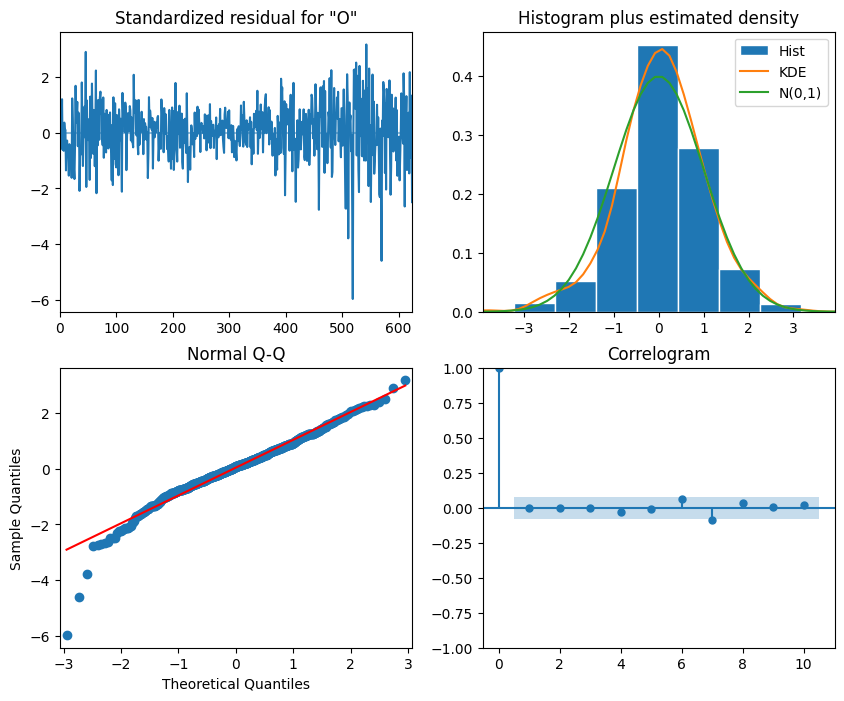

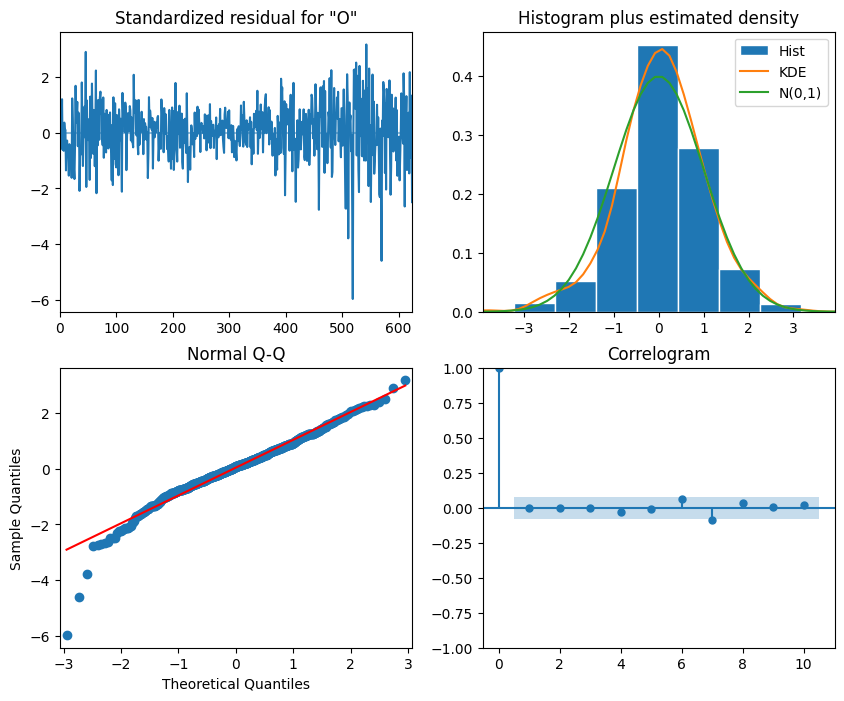

In [0]:
SARIMA_model = SARIMAX(train, exog=exog_train, order=(p,d,q), seasonal_order=(P,D,Q,12), simple_differencing=False, trend="c")
SARIMA_model_fit = SARIMA_model.fit(disp=False, maxiter=500)

SARIMA_model_fit.plot_diagnostics(figsize=(10,8))

In [0]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np

residuals = SARIMA_model_fit.resid

lb_test = acorr_ljungbox(
    residuals,
    lags=np.arange(1, 11, 1),
    return_df=True
)

print(lb_test)

     lb_stat  lb_pvalue
1   0.000018   0.996618
2   0.027245   0.986470
3   0.048969   0.997160
4   0.826893   0.934807
5   1.069852   0.956737
6   1.600233   0.952561
7   3.776492   0.805131
8   3.830140   0.872114
9   3.931647   0.915853
10  4.072840   0.944001


## Model Training Strategy

**Two-stage approach:**

1. **Model Selection (Cells 35-49):** Train SARIMA and Prophet on the **training set only** (all data except last 12 months), then evaluate on the test set to select the best model.

2. **Final Forecast (Cells 54+):** Retrain BOTH models on the **full dataset** (all historical data) before generating the 5-year production forecast. This ensures both models use all available information for the final forecast.

This approach ensures:
* Fair model comparison (both use same training data)
* Maximum data utilization for production forecasts
* Consistent coefficient extraction (from full-data model)

It passes the plots and the ljungbox test, so use it for forecasting

## Create a Prophet model for comparison

In [0]:
%pip install prophet

from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data for Prophet using ONLY the training set (consistent with SARIMA)
# This ensures fair comparison - both models trained on same data
train_size = len(df_pd) - 12
prophet_df = df_pd[['Date', 'Oil_Prod']].iloc[:train_size].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Add exogenous variable to Prophet training data (if available)
if exogenous_variables is not None:
    prophet_df['exog_scenario'] = exogenous_variables[:train_size]

# Initialize and fit Prophet model
print("Training Prophet model...")
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # Oil production often has multiplicative seasonality
    changepoint_prior_scale=0.05  # Controls flexibility of trend
)

# Add exogenous regressor if available
if exogenous_variables is not None:
    model.add_regressor('exog_scenario')
    print("Added exogenous scenario variable as regressor")

model.fit(prophet_df)
print("Prophet model trained successfully!")

# Create future dataframe for 72 months (12 for test set + 60 for 5-year forecast)
# Prophet was trained on training set, so needs to forecast through test period AND 5 years beyond
future = model.make_future_dataframe(periods=72, freq='MS')

# Add exogenous variable to future dataframe (if available)
if exogenous_variables is not None:
    # Need to provide exog values for: training period + test period (12) + forecast period (60)
    future['exog_scenario'] = exogenous_variables[:len(future)]

# Make predictions
print("Generating 5-year forecast...")
forecast = model.predict(future)

print(f"Forecast generated from {forecast['ds'].min()} to {forecast['ds'].max()}")

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Training Prophet model...
Added exogenous scenario variable as regressor


16:07:53 - cmdstanpy - INFO - Chain [1] start processing
16:07:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!
Generating 5-year forecast...
Forecast generated from 1973-01-01 00:00:00 to 2031-02-01 00:00:00


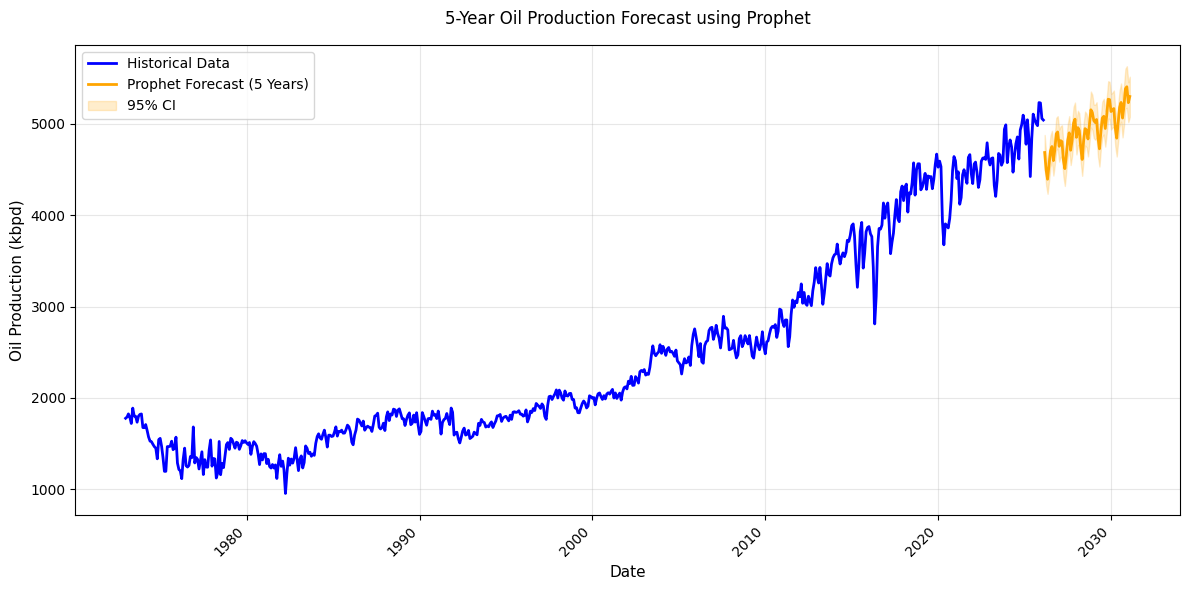


Forecast Summary:
Last historical value: 5042.60 kbpd (2026-02)
Forecasted value in 60 months: 5300.49 kbpd (2031-02)
Change: 5.11%


In [0]:
# Plot Prophet forecast
fig, ax = plt.subplots(figsize=(12, 6))

# Plot ALL historical data (including test set for visualization)
full_hist_df = df_pd[['Date', 'Oil_Prod']].copy()
full_hist_df['Date'] = pd.to_datetime(full_hist_df['Date'])
ax.plot(full_hist_df['Date'], full_hist_df['Oil_Prod'], label='Historical Data', color='blue', linewidth=2)

# Plot Prophet forecast (only 5-year future beyond full dataset)
last_full_date = pd.to_datetime(df_pd['Date'].iloc[-1])
forecast_future = forecast[forecast['ds'] > last_full_date]
ax.plot(forecast_future['ds'], forecast_future['yhat'], label='Prophet Forecast (5 Years)', color='orange', linewidth=2)

# Plot confidence intervals for forecast
ax.fill_between(forecast_future['ds'], 
                forecast_future['yhat_lower'], 
                forecast_future['yhat_upper'], 
                color='orange', alpha=0.2, label='95% CI')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Oil Production (kbpd)', fontsize=11)
ax.set_title('5-Year Oil Production Forecast using Prophet', fontsize=12, pad=15)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nForecast Summary:")
print(f"Last historical value: {full_hist_df['Oil_Prod'].iloc[-1]:.2f} kbpd ({full_hist_df['Date'].iloc[-1].strftime('%Y-%m')})")
print(f"Forecasted value in 60 months: {forecast_future['yhat'].iloc[-1]:.2f} kbpd ({forecast_future['ds'].iloc[-1].strftime('%Y-%m')})")
print(f"Change: {((forecast_future['yhat'].iloc[-1] / full_hist_df['Oil_Prod'].iloc[-1]) - 1) * 100:.2f}%")

In [0]:
# Calculate dynamic indices for naive forecast (12 months before test set)
train_end_idx = len(df_pd) - 12
naive_start_idx = train_end_idx - 12
naive_end_idx = train_end_idx

# Naive forecast using previous 12 months as forecast for next 12 months
test['naive_seasonal'] = df_pd['Oil_Prod'].iloc[naive_start_idx:naive_end_idx].values

# SARIMA predictions for test period using dynamic indices
test_start_idx = len(df_pd) - 12
test_end_idx = len(df_pd)

# Prepare exog for test period
if exogenous_variables is not None:
    exog_test = exogenous_variables[len(train):len(train)+12]
    SARIMA_pred = SARIMA_model_fit.get_prediction(test_start_idx, test_end_idx - 1, exog=exog_test)
else:
    SARIMA_pred = SARIMA_model_fit.get_prediction(test_start_idx, test_end_idx - 1)

test['SARIMA_pred'] = SARIMA_pred.predicted_mean.values

# Extract Prophet predictions for the test period
test_dates = pd.to_datetime(test['Date'])
prophet_test_pred = forecast[forecast['ds'].isin(test_dates)]['yhat'].values
test['Prophet_pred'] = prophet_test_pred

/home/spark-91d62608-ac39-4865-9ad4-1f/.ipykernel/73/command-6013300546954080-1752428557:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_seasonal'] = df_pd['Oil_Prod'].iloc[naive_start_idx:naive_end_idx].values
/home/spark-91d62608-ac39-4865-9ad4-1f/.ipykernel/73/command-6013300546954080-1752428557:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['SARIMA_pred'] = SARIMA_pred.predicted_mean.values
/home/spark-91d62608-ac39-4865-9ad4-1f/.ipykernel/73/command-6013300546954080-1752428557:25: 

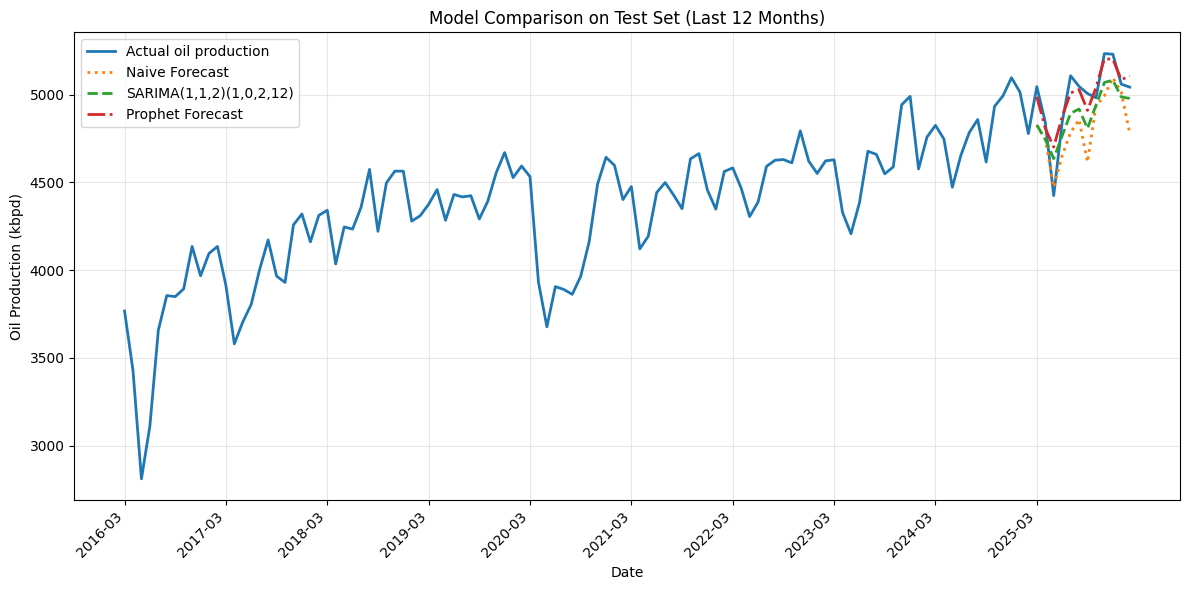

In [0]:
#now plot test and train (the last 120 steps)
plot_df = df_pd.iloc[-120:]

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(plot_df['Date'], plot_df['Oil_Prod'], label='Actual oil production', linewidth=2)
ax.plot(test['Date'], test['naive_seasonal'], label='Naive Forecast', linestyle=':', linewidth=2)
ax.plot(test['Date'], test['SARIMA_pred'], label=f'SARIMA({p},{d},{q})({P},{D},{Q},12)', linestyle='--', linewidth=2)
ax.plot(test['Date'], test['Prophet_pred'], label='Prophet Forecast', linestyle='-.', linewidth=2)
ax.legend()
ax.set_xlabel('Date')
ax.set_ylabel('Oil Production (kbpd)')
ax.set_title('Model Comparison on Test Set (Last 12 Months)')
ax.grid(True, alpha=0.3)

# Set x-ticks every 12 months to avoid overcrowding
tick_positions = np.arange(0, len(plot_df), 12)
tick_labels = plot_df['Date'].iloc[tick_positions].values
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

Now compare the accuracy of the models.

In [0]:
#now compare MAPE

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_seasonal = mape(test['Oil_Prod'], test['naive_seasonal'])
mape_SARIMA = mape(test['Oil_Prod'], test['SARIMA_pred'])
mape_Prophet = mape(test['Oil_Prod'], test['Prophet_pred'])

print(f"Naive Seasonal MAPE: {mape_naive_seasonal:.2f}%")
print(f"SARIMA MAPE: {mape_SARIMA:.2f}%")
print(f"Prophet MAPE: {mape_Prophet:.2f}%")

Naive Seasonal MAPE: 3.62%
SARIMA MAPE: 2.75%
Prophet MAPE: 1.42%


##Chart the comparison

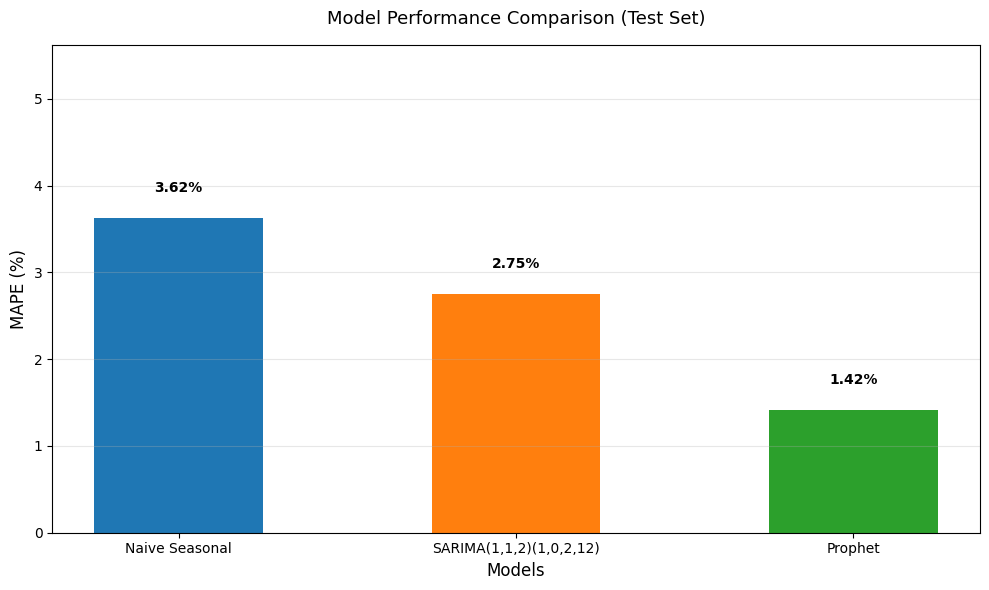

In [0]:
#plot

fig, ax = plt.subplots(figsize=(10, 6))

x = ['Naive Seasonal', f'SARIMA({p},{d},{q})({P},{D},{Q},12)', 'Prophet']
y = [mape_naive_seasonal, mape_SARIMA, mape_Prophet]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
ax.bar(x, y, width=0.5, color=colors)
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_ylim(0, max(y) + 2)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=13, pad=15)
ax.grid(True, alpha=0.3, axis='y')

for index, value in enumerate(y):
    plt.text(x=index, y=value + 0.3, s=str(round(value,2)) + '%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()

In [0]:
#display the train dataframe
# display(train)

# Use the winning model (out of SARIMA or Prophet) to plot and save the forecast, including confidence intervals

In [0]:
# Retrain BOTH models on the entire dataset for final 5-year forecast
# This ensures both models use all available data for the production forecast

print("Retraining SARIMA on full dataset...")
if exogenous_variables is not None:
    exog_full = exogenous_variables[:len(df_pd)]
    SARIMA_full_model = SARIMAX(df_pd['Oil_Prod'], exog=exog_full, order=(p,d,q), seasonal_order=(P,D,Q,12), simple_differencing=False, trend="c")
else:
    SARIMA_full_model = SARIMAX(df_pd['Oil_Prod'], order=(p,d,q), seasonal_order=(P,D,Q,12), simple_differencing=False, trend="c")

SARIMA_full_model_fit = SARIMA_full_model.fit(disp=False, maxiter=500)

print("Retraining Prophet on full dataset...")
# Prepare Prophet data using the FULL dataset (not just training)
prophet_full_df = df_pd[['Date', 'Oil_Prod']].copy()
prophet_full_df.columns = ['ds', 'y']
prophet_full_df['ds'] = pd.to_datetime(prophet_full_df['ds'])

# Add exogenous variable to Prophet full data (if available)
if exogenous_variables is not None:
    prophet_full_df['exog_scenario'] = exogenous_variables[:len(df_pd)]

# Initialize and fit Prophet model on full dataset
model_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

if exogenous_variables is not None:
    model_full.add_regressor('exog_scenario')

model_full.fit(prophet_full_df)

# Create future dataframe for 5-year forecast (60 months)
future_full = model_full.make_future_dataframe(periods=60, freq='MS')

# Add exogenous variable to future dataframe (if available)
if exogenous_variables is not None:
    future_full['exog_scenario'] = exogenous_variables[:len(future_full)]

# Generate forecast
forecast_full = model_full.predict(future_full)

# Forecast for the next 60 months (5 years)
if exogenous_variables is not None:
    exog_forecast = exogenous_variables[len(df_pd):len(df_pd)+60]
    SARIMA_forecast = SARIMA_full_model_fit.get_forecast(60, exog=exog_forecast)
else:
    SARIMA_forecast = SARIMA_full_model_fit.get_forecast(60)
SARIMA_forecast_conf = SARIMA_forecast.conf_int(alpha=0.05)
SARIMA_forecast_df = pd.concat([SARIMA_forecast.predicted_mean, SARIMA_forecast_conf], axis=1)
SARIMA_forecast_df.columns = ['SARIMA_forecast', 'SARIMA_forecast_lower', 'SARIMA_forecast_upper']

# Generate proper date range for the forecast (dynamic, based on last date)
last_date = pd.to_datetime(df_pd['Date'].iloc[-1])
forecast_dates = pd.date_range(start=last_date, periods=len(SARIMA_forecast_df) + 1, freq='MS')[1:]
SARIMA_forecast_df.index = forecast_dates

# Convert historical dates to datetime for consistent plotting
df_pd_plot = df_pd.copy()
df_pd_plot['Date'] = pd.to_datetime(df_pd_plot['Date'])


Retraining SARIMA on full dataset...
Retraining Prophet on full dataset...


16:08:08 - cmdstanpy - INFO - Chain [1] start processing
16:08:08 - cmdstanpy - INFO - Chain [1] done processing


In [0]:
# Select the best model based on MAPE
if mape_Prophet < mape_SARIMA:
    print(f"✓ Prophet selected as best model (MAPE: {mape_Prophet:.2f}% vs SARIMA: {mape_SARIMA:.2f}%)")
    winning_model = 'Prophet'
    winning_mape = mape_Prophet
    
    # Prepare Prophet forecast dataframe (5 years beyond FULL dataset, not just training)
    # Use forecast_full which was generated from the model retrained on full data
    last_full_date = pd.to_datetime(df_pd['Date'].iloc[-1])
    forecast_future = forecast_full[forecast_full['ds'] > last_full_date].copy()
    best_forecast_df = pd.DataFrame({
        'Date': forecast_future['ds'],
        'Forecast': forecast_future['yhat'],
        'Forecast_Lower': forecast_future['yhat_lower'],
        'Forecast_Upper': forecast_future['yhat_upper']
    }).reset_index(drop=True)
else:
    print(f"✓ SARIMA selected as best model (MAPE: {mape_SARIMA:.2f}% vs Prophet: {mape_Prophet:.2f}%)")
    winning_model = 'SARIMA'
    winning_mape = mape_SARIMA
    
    # Prepare SARIMA forecast dataframe
    best_forecast_df = pd.DataFrame({
        'Date': SARIMA_forecast_df.index,
        'Forecast': SARIMA_forecast_df['SARIMA_forecast'],
        'Forecast_Lower': SARIMA_forecast_df['SARIMA_forecast_lower'],
        'Forecast_Upper': SARIMA_forecast_df['SARIMA_forecast_upper']
    }).reset_index(drop=True)

print(f"\nForecast details:")
print(f"  Periods: {len(best_forecast_df)} months")
print(f"  Date range: {best_forecast_df['Date'].min()} to {best_forecast_df['Date'].max()}")
print(f"  Final forecast value: {best_forecast_df['Forecast'].iloc[-1]:.2f} kbpd")

# Prepare historical data (only actual historical values)
hist_df = df_pd_plot[['Date', 'Oil_Prod']].copy()
hist_df['Total_crude_forecast'] = None
hist_df['Total_Lower_Bound'] = None
hist_df['Total_Upper_Bound'] = None

# Get the last month of historical data to include in forecast column (for visual connection)
last_month = hist_df.tail(1).copy()
last_month['Total_crude_forecast'] = last_month['Oil_Prod']  # Copy last month to forecast column for connection

# Update the last month in hist_df
hist_df.iloc[-1, hist_df.columns.get_loc('Total_crude_forecast')] = last_month['Total_crude_forecast'].values[0]

# Prepare forecast data (future only, no historical)
forecast_df = best_forecast_df.copy()
forecast_df['Oil_Prod'] = None  # No historical values in forecast rows
forecast_df = forecast_df.rename(columns={
    'Forecast': 'Total_crude_forecast',
    'Forecast_Lower': 'Total_Lower_Bound',
    'Forecast_Upper': 'Total_Upper_Bound'
})

# Clip forecast values to ensure they never go below 0
# Oil production cannot be negative
forecast_df['Total_crude_forecast'] = forecast_df['Total_crude_forecast'].clip(lower=0)
forecast_df['Total_Lower_Bound'] = forecast_df['Total_Lower_Bound'].clip(lower=0)
forecast_df['Total_Upper_Bound'] = forecast_df['Total_Upper_Bound'].clip(lower=0)

# Combine historical and forecast data
base_timeseries_df = pd.concat([hist_df, forecast_df], ignore_index=True)
base_timeseries_df = base_timeseries_df.sort_values(by='Date').reset_index(drop=True)

# Add Country and Scenario columns
base_timeseries_df['Country'] = country
base_timeseries_df['Scenario'] = scenario_sanitized  # Use sanitized scenario name

# Rename Oil_Prod to Total_crude
base_timeseries_df = base_timeseries_df.rename(columns={'Oil_Prod': 'Total_crude'})

# Reorder columns to match forecast_table_monthly schema
base_timeseries_df = base_timeseries_df[[
    'Country', 'Scenario', 'Date', 'Total_crude', 'Total_Lower_Bound', 'Total_Upper_Bound',
    'Total_crude_forecast'
]]

# Save to forecast_table_monthly, replacing existing data for this country+scenario
print(f"\nUpdating forecast_table_monthly for {country} - {scenario_sanitized}...")

# Delete existing entries for this country+scenario
print(f"  Deleting existing entries for {country} + {scenario_sanitized}...")
spark.sql(f"""
    DELETE FROM workspace.gold.production_forecast_table_monthly 
    WHERE Country = '{country}' AND Scenario = '{scenario_sanitized}'
""")

# Insert new data
print(f"  Inserting {len(base_timeseries_df)} rows...")
spark.createDataFrame(base_timeseries_df).write.mode('append').saveAsTable('workspace.gold.production_forecast_table_monthly')
print(f"✓ Forecast saved successfully to forecast_table!")

✓ Prophet selected as best model (MAPE: 1.42% vs SARIMA: 2.75%)

Forecast details:
  Periods: 60 months
  Date range: 2026-03-01 00:00:00 to 2031-02-01 00:00:00
  Final forecast value: 5262.91 kbpd

Updating forecast_table for Canada - covid_shutdowns...
  Deleting existing entries for Canada + covid_shutdowns...


/home/spark-91d62608-ac39-4865-9ad4-1f/.ipykernel/73/command-6013300546954089-2681424084:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_timeseries_df = pd.concat([hist_df, forecast_df], ignore_index=True)


  Inserting 698 rows...
✓ Forecast saved successfully to forecast_table!


In [0]:
# Display the forecast table for validation (filtered to this country+scenario)
display(spark.sql(f"""
    SELECT * FROM workspace.gold.production_forecast_table_monthly 
    WHERE Country = '{country}' AND Scenario = '{scenario_sanitized}'
    ORDER BY Date
"""))

Country,Date,Total_crude,Total_Lower_Bound,Total_Upper_Bound,Source_Table,Scenario,Total_crude_forecast,Heavy_Crude_Percent,Heavy_crude,Heavy_crude_forecast,Heavy_Lower_Bound,Heavy_Upper_Bound,generic_name,event_direction
Canada,1973-01-01T00:00:00.000Z,1778.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-02-01T00:00:00.000Z,1792.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-03-01T00:00:00.000Z,1826.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-04-01T00:00:00.000Z,1787.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-05-01T00:00:00.000Z,1721.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-06-01T00:00:00.000Z,1889.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-07-01T00:00:00.000Z,1803.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-08-01T00:00:00.000Z,1799.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-09-01T00:00:00.000Z,1735.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null
Canada,1973-10-01T00:00:00.000Z,1802.0,null,null,null,covid_shutdowns,null,null,null,null,null,null,null,null


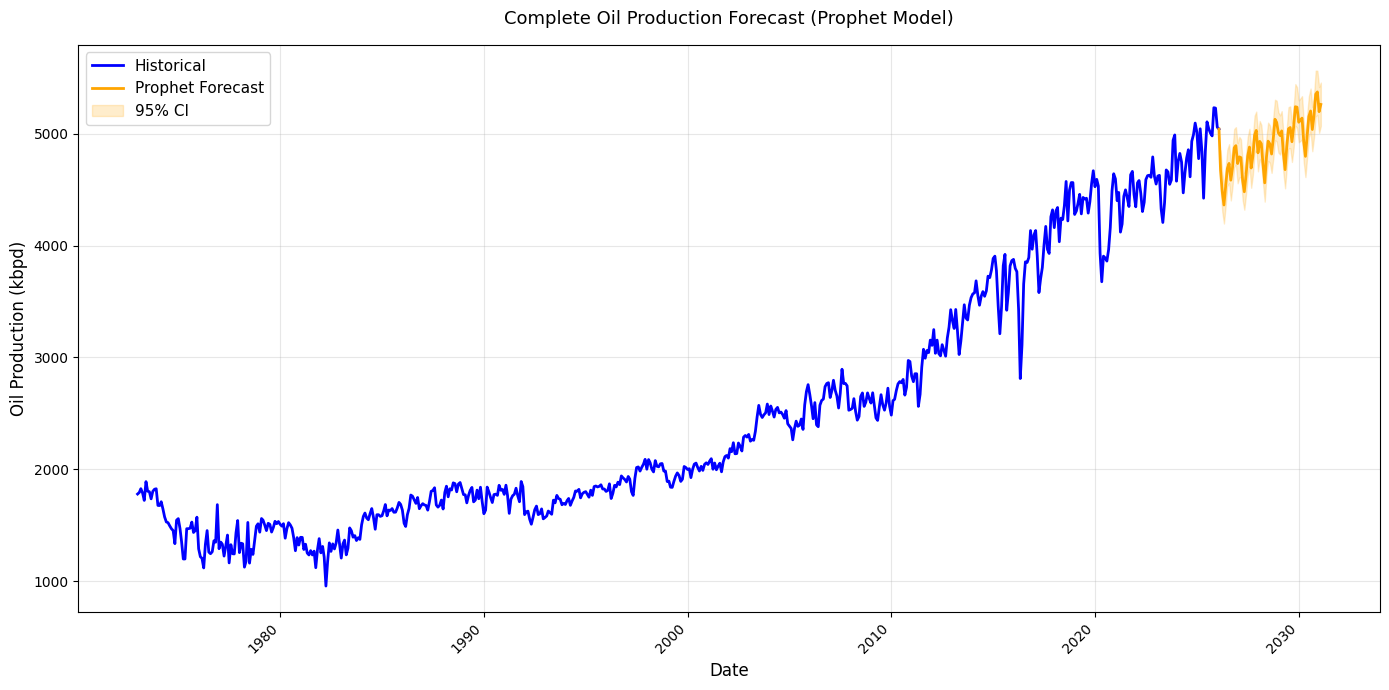


FORECAST VALIDATION SUMMARY
Winning Model: Prophet
Historical data ends: 2026-02
Forecast extends to: 2031-02
Final forecast value: 5262.91 kbpd
95% CI: [5070.38, 5458.51] kbpd


In [0]:
# Plot the complete timeseries with confidence intervals
plot_df = spark.sql(f"""
    SELECT * FROM workspace.gold.production_forecast_table_monthly 
    WHERE Country = '{country}' AND Scenario = '{scenario_sanitized}'
    ORDER BY Date
""").toPandas()

# Rename columns back for plotting compatibility
plot_df = plot_df.rename(columns={
    'Total_crude': 'Oil_Prod',
    'Total_Lower_Bound': 'Forecast_Lower',
    'Total_Upper_Bound': 'Forecast_Upper'
})
plot_df['Date'] = pd.to_datetime(plot_df['Date'])
plot_df = plot_df.sort_values(by='Date').reset_index(drop=True)

# Identify the last date in the historical data
last_hist_date = pd.to_datetime(df_pd_plot['Date'].iloc[-1])

# Create masks for historical and forecast periods
hist_mask = plot_df['Date'] <= last_hist_date
forecast_mask = plot_df['Date'] > last_hist_date

fig, ax = plt.subplots(figsize=(14, 7))

# Plot historical data in blue
ax.plot(plot_df.loc[hist_mask, 'Date'], plot_df.loc[hist_mask, 'Oil_Prod'], 
        color='blue', linewidth=2, label='Historical')

# Plot forecast data in orange
forecast_data = plot_df.loc[forecast_mask]

# Get the last historical point to connect the lines
last_hist_point = plot_df.loc[hist_mask].iloc[-1:]
forecast_with_connection = pd.concat([last_hist_point, forecast_data])

ax.plot(forecast_with_connection['Date'], forecast_with_connection['Total_crude_forecast'], 
        color='orange', linewidth=2, label=f'{winning_model} Forecast')

# Plot confidence intervals for forecast period (starting from the connection point)
ax.fill_between(forecast_with_connection['Date'], 
                forecast_with_connection['Forecast_Lower'], 
                forecast_with_connection['Forecast_Upper'], 
                color='orange', alpha=0.2, label='95% CI')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Oil Production (kbpd)', fontsize=12)
ax.set_title(f'Complete Oil Production Forecast ({winning_model} Model)', fontsize=13, pad=15)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"FORECAST VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Winning Model: {winning_model}")
print(f"Historical data ends: {last_hist_date.strftime('%Y-%m')}")
print(f"Forecast extends to: {forecast_data['Date'].max().strftime('%Y-%m')}")
print(f"Final forecast value: {forecast_data['Total_crude_forecast'].iloc[-1]:.2f} kbpd")
print(f"95% CI: [{forecast_data['Forecast_Lower'].iloc[-1]:.2f}, {forecast_data['Forecast_Upper'].iloc[-1]:.2f}] kbpd")
print(f"{'='*60}")

In [0]:
# Extract the coefficient of the exogenous variable from the winning model (if exog is used)
if exogenous_variables is not None:
    print(f"\n{'='*60}")
    print(f"EXOGENOUS VARIABLE COEFFICIENT ANALYSIS")
    print(f"{'='*60}")
    print(f"Scenario: {scenario}")
    print(f"Model: {winning_model}")
    
    if winning_model == 'SARIMA':
        # For SARIMA, the exog coefficient is in the params
        # The first exogenous variable is typically labeled as 'x1'
        params = SARIMA_full_model_fit.params
        if 'x1' in params.index:
            exog_coef = params['x1']
            print(f"\nExogenous Variable Coefficient: {exog_coef:.6f}")
            print(f"\nInterpretation:")
            if exog_coef > 0:
                print(f"  → Positive coefficient: The scenario event is associated with an INCREASE in oil production")
                print(f"  → A 1-unit increase in the scenario variable increases production by ~{exog_coef:.2f} kbpd")
            else:
                print(f"  → Negative coefficient: The scenario event is associated with a DECREASE in oil production")
                print(f"  → A 1-unit increase in the scenario variable decreases production by ~{abs(exog_coef):.2f} kbpd")
        else:
            print("\nWarning: Exogenous coefficient 'x1' not found in model parameters")
            print(f"Available parameters: {params.index.tolist()}")
    
    elif winning_model == 'Prophet':
        # For Prophet, regressor coefficients are stored in the 'beta' array in model.params
        # The beta array contains: [seasonality_coefficients..., regressor_coefficients...]
        # Regressors are at the end of the beta array
        # Use model_full which was retrained on the full dataset
        
        if len(model_full.extra_regressors) > 0:
            beta_array = model_full.params['beta'][0]  # Extract from (1, n) shape to (n,) array
            # The regressor coefficient is at index -(number of regressors)
            regressor_index = -len(model_full.extra_regressors)
            exog_coef = beta_array[regressor_index]
            
            print(f"\nExogenous Variable Coefficient: {exog_coef:.6f}")
            print(f"\nInterpretation:")
            if exog_coef > 0:
                print(f"  → Positive coefficient: The scenario event is associated with an INCREASE in oil production")
                print(f"  → The scenario adds approximately {exog_coef:.2f} kbpd to the baseline forecast")
            else:
                print(f"  → Negative coefficient: The scenario event is associated with a DECREASE in oil production")
                print(f"  → The scenario reduces approximately {abs(exog_coef):.2f} kbpd from the baseline forecast")
        else:
            print("\nWarning: No exogenous regressors found in Prophet model")
    
    print(f"{'='*60}")
    
    # update the coefficient to workspace.gold.exogenous_variables table
    print(f"\nSaving coefficient to workspace.gold.exogenous_variables...")

    spark.sql(f"""
        UPDATE workspace.gold.exogenous_variables
        SET Coefficient = {exog_coef}
        WHERE Country = '{country}' AND Description = '{scenario}'
    """)
    
    print(f"✓ Coefficient {exog_coef:.6f} saved for {country} - {scenario}")
    print(f"{'='*60}")
else:
    print("\nNo exogenous variable used (Baseline scenario)")


EXOGENOUS VARIABLE COEFFICIENT ANALYSIS
Scenario: COVID Shutdowns
Model: Prophet

Exogenous Variable Coefficient: -0.085343

Interpretation:
  → Negative coefficient: The scenario event is associated with a DECREASE in oil production
  → The scenario reduces approximately 0.09 kbpd from the baseline forecast

Saving coefficient to workspace.gold.exogenous_variables...
✓ Coefficient -0.085343 saved for Canada - COVID Shutdowns


In [0]:
# Calculate total execution time
notebook_end_time = time.time()
total_seconds = notebook_end_time - notebook_start_time

# Format the output
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)

print("="*50)
print(f"Notebook execution completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total execution time: {minutes} minutes and {seconds} seconds")
print(f"Total execution time: {total_seconds:.2f} seconds")
print("="*50)

Notebook execution completed at: 2026-08-06 16:08:25
Total execution time: 10 minutes and 32 seconds
Total execution time: 632.82 seconds


In [0]:
#Save model run metrics to gold.model_metrics, replacing other model runs for this Country+Scenario+Direction combination

#Add parameters to winning_model if model is SARIMA
if winning_model == 'SARIMA':
    winning_model = f'SARIMA({p},{d},{q})({P},{D},{Q},12)'

# Initialize exog_coef if not already set (for baseline scenarios or when coefficient wasn't found)
if 'exog_coef' not in locals():
    exog_coef = 0

#if it doesn't exist, create table model_metrics
spark.sql(f"""
    CREATE TABLE IF NOT EXISTS workspace.gold.model_metrics (
        Country string,
        Scenario string,
        Direction string,
        Date_of_run TIMESTAMP,
        Best_model string,
        MAPE string,
        Coefficient DOUBLE
    )
""")

# Delete existing entry for this Country+Scenario+Direction combination
spark.sql(f"""
    DELETE FROM workspace.gold.model_metrics
    WHERE Country = '{country}' 
      AND Scenario = '{scenario_sanitized}' 
      AND Direction = 'Production'
""")

# Insert new model run metrics
spark.sql(f"""
    INSERT INTO workspace.gold.model_metrics (Country, Scenario, Direction, Best_model, MAPE, Date_of_run, Coefficient)
    VALUES ('{country}', '{scenario_sanitized}', 'Production', '{winning_model}', '{winning_mape:.2f}', '{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}', {exog_coef})
""")


DataFrame[num_affected_rows: bigint, num_inserted_rows: bigint]